In [1]:
from pathlib import Path
import numpy as np
import rasterio
import matplotlib.pyplot as plt

In [9]:
ROOT = Path("D:/GeoPipe/data/07_water_masks/engenheiro_avidos/s2cloudless/temporal_interpolation")

METHODS = [
    "deepwatermap",
    "watnet",
    "vgg-unet"
]

OUTPUT = Path("D:/GeoPipe/notebooks/probabilities_analisys/data")
OUTPUT.mkdir(exist_ok=True)

In [14]:
files = sorted((ROOT / METHODS[0]).rglob("*.tif"))

In [15]:
len(files)

598

KeyboardInterrupt: 

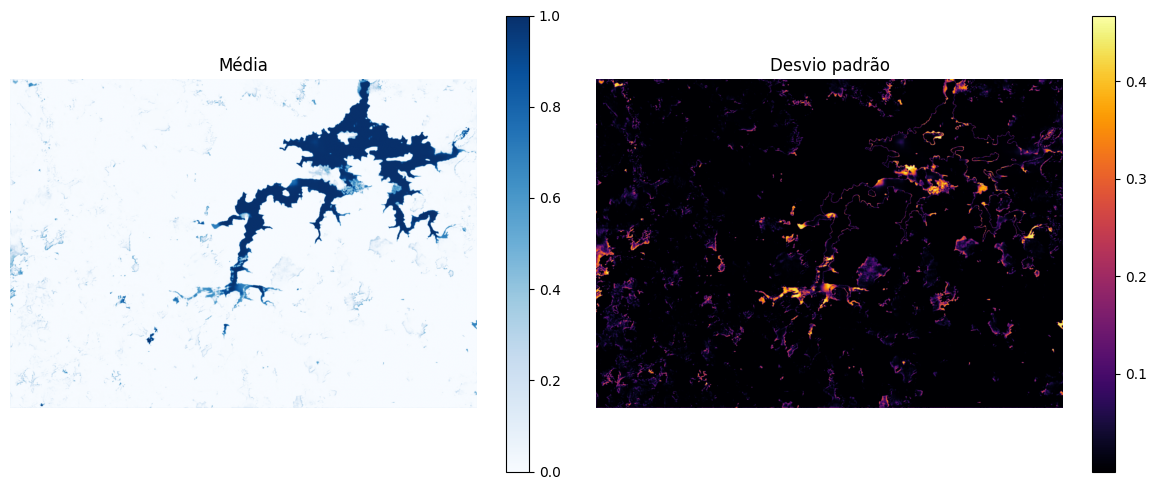

In [16]:
for file in files:

    # Ex.: 2020/boqueirao_2020_01.tif
    relative_path = file.relative_to(ROOT / METHODS[0])

    arrays = []
    profile = None

    for method in METHODS:

        path = ROOT / method / relative_path

        if not path.exists():
            print(f"Arquivo não encontrado: {path}")
            break

        with rasterio.open(path) as src:

            img = src.read(1).astype(np.float32)

            if profile is None:
                profile = src.profile

        arrays.append(img)

    # Caso algum método esteja faltando
    if len(arrays) != len(METHODS):
        continue

    stack = np.stack(arrays)

    mean_map = np.mean(stack, axis=0)
    std_map = np.std(stack, axis=0)

    # Mantém a mesma estrutura de anos
    output_dir = OUTPUT / relative_path.parent
    output_dir.mkdir(parents=True, exist_ok=True)

    profile.update(dtype="float32", count=1)

    # Salva média
    with rasterio.open(
        output_dir / f"{relative_path.stem}_mean.tif",
        "w",
        **profile
    ) as dst:
        dst.write(mean_map.astype(np.float32), 1)

    # Salva desvio padrão
    with rasterio.open(
        output_dir / f"{relative_path.stem}_std.tif",
        "w",
        **profile
    ) as dst:
        dst.write(std_map.astype(np.float32), 1)

    # Figura
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    im = ax[0].imshow(mean_map, cmap="Blues", vmin=0, vmax=1)
    ax[0].set_title("Média")
    ax[0].axis("off")
    plt.colorbar(im, ax=ax[0])

    im = ax[1].imshow(std_map, cmap="inferno")
    ax[1].set_title("Desvio padrão")
    ax[1].axis("off")
    plt.colorbar(im, ax=ax[1])

    plt.tight_layout()
    plt.savefig(output_dir / f"{relative_path.stem}.png", dpi=300)
    plt.close()

print("Processamento concluído!")